In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df = pd.read_csv("player_stats.csv", encoding='latin1', on_bad_lines='skip')
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


In [3]:
df.shape

(5682, 41)

In [4]:
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,...,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,0.0,5682.000000,5682.000000,5682.000000,5682.000000,...,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.00000,5682.000000,5682.000000,5682.000000
mean,181.670539,75.282295,26.316262,58.912179,56.128476,NaN,46.728441,48.820838,56.324006,61.959345,...,47.164203,48.099789,43.299542,48.174938,42.931890,16.187610,16.43805,16.191834,16.071982,16.570222
std,6.829238,6.998971,4.729967,16.567068,18.772075,NaN,20.519430,20.975966,16.846410,8.893309,...,19.463368,18.086672,17.086473,15.781737,17.912619,17.146572,17.63526,16.993154,16.808674,17.942154
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,...,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.00000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,...,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.00000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,...,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.00000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,...,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.00000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,...,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.00000,87.000000,90.000000,89.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [6]:
df.drop(columns=['player'],axis=1, inplace=True)


In [7]:
df.isnull().sum()

,0
country,0
height,0
weight,0
age,0
club,0
ball_control,0
dribbling,0
marking,5682
slide_tackle,0
stand_tackle,0


In [8]:
df.drop('marking', axis=1, inplace=True)

In [9]:
df.isnull().sum()

,0
country,0
height,0
weight,0
age,0
club,0
ball_control,0
dribbling,0
slide_tackle,0
stand_tackle,0
aggression,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
catgorical_col=df.select_dtypes(include="object")
numerical_col=df.select_dtypes(exclude="object")

In [17]:
catgorical_col

,country,club,value
0,Colombia,Atl. Nacional,$1.400.000
1,Brazil,Corinthians,$975.00
2,Germany,Holstein Kiel,$1.100.000
3,Austria,SK Rapid Wien,$650.00
4,Uruguay,Independiente,$300.00
...,...,...,...
5677,Egypt,Liverpool,$99.500.000
5678,Senegal,FC Bayern München,$101.000.000
5679,Brazil,Paris SG,$99.500.000
5680,Portugal,Al Nassr,$31.000.000


In [18]:
numerical_col

,height,weight,age,ball_control,dribbling,slide_tackle,stand_tackle,aggression,reactions,att_position,...,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
0,192,84,22,55,43,68,73,72,68,30,...,31,32,34,41,33,10,11,6,7,9
1,181,80,31,69,70,56,58,62,70,69,...,68,65,62,48,46,12,15,14,8,14
2,193,84,29,25,12,13,16,27,65,17,...,20,20,15,26,16,64,74,65,68,74
3,187,86,33,46,48,66,69,71,64,48,...,33,25,13,22,19,10,10,8,14,9
4,191,80,23,14,8,14,16,28,50,10,...,6,9,10,16,5,61,59,62,64,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,175,71,31,86,88,41,43,63,92,91,...,84,84,69,86,83,11,14,14,9,14
5678,174,69,31,86,88,38,42,75,91,90,...,78,77,64,75,75,7,10,10,15,14
5679,175,68,31,94,95,29,32,63,88,86,...,81,88,87,91,86,15,9,9,15,11
5680,187,83,38,87,81,24,32,62,90,93,...,88,79,75,90,85,14,7,11,15,11


In [ ]:
for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]



In [19]:
df.shape

(5679, 39)

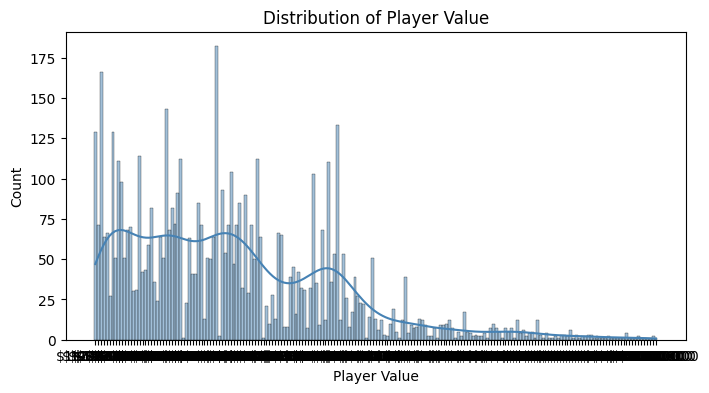

In [20]:
# Univariate - Distribution of Target Variable
plt.figure(figsize=(8,4))
sns.histplot(df['value'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Player Value')
plt.xlabel('Player Value')
plt.show()

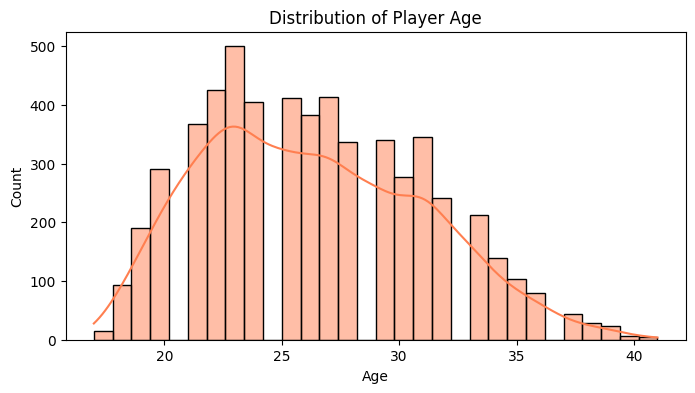

In [21]:
# Univariate - Age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True, color='coral')
plt.title('Distribution of Player Age')
plt.xlabel('Age')
plt.show()

Age distribution indicates majority of players fall within a specific age range

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [25]:
df.head()

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,24,192,84,22,63,55,43,68,73,72,...,32,34,41,33,10,11,6,7,9,4
1,14,181,80,31,154,69,70,56,58,62,...,65,62,48,46,12,15,14,8,14,189
2,47,193,84,29,315,25,12,13,16,27,...,20,15,26,16,64,74,65,68,74,1
3,8,187,86,33,535,46,48,66,69,71,...,25,13,22,19,10,10,8,14,9,159
4,130,191,80,23,330,14,8,14,16,28,...,9,10,16,5,61,59,62,64,64,96


In [27]:
X = df.drop(columns=['value'])
y = df['value']


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4543, 38), (1136, 38), (4543,), (1136,))

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
# Initialize and train
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [32]:
# Predict
y_pred_lr = lr.predict(X_test_scaled)


In [35]:
mse_lr  = mean_squared_error(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)


In [36]:
mse_lr

4271.550818769421

In [37]:
mae_lr

58.91108753561492

In [38]:
r2_lr

0.005320438489463286

In [39]:
# Initialize and train
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate
mse_rf  = mean_squared_error(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)



In [40]:
mse_rf

3135.071967165493

In [41]:
mae_rf

44.554674295774646

In [42]:
r2_rf

0.269962563502284

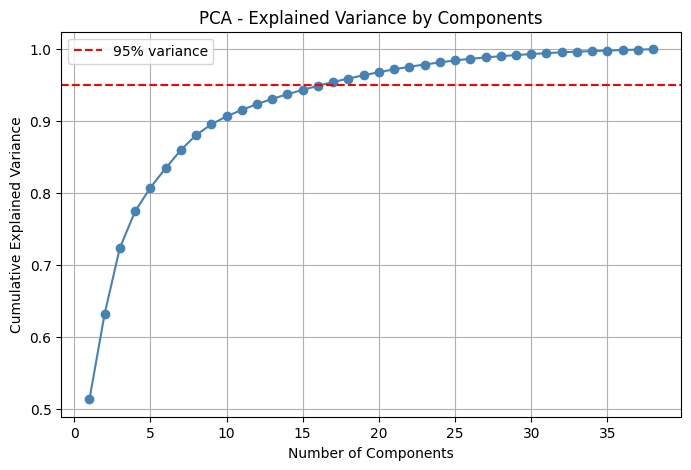

In [43]:
# Apply PCA
pca = PCA()
pca.fit(X_train_scaled)

# Plot explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance by Components')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# Select optimal number of components (95% variance explained)
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Optimal number of components to explain 95% variance: {n_components}')

# Apply PCA with optimal components
pca_opt = PCA(n_components=n_components)
X_train_pca = pca_opt.fit_transform(X_train_scaled)
X_test_pca  = pca_opt.transform(X_test_scaled)

print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape: ', X_test_pca.shape)

Optimal number of components to explain 95% variance: 17
X_train_pca shape: (4543, 17)
X_test_pca shape:  (1136, 17)


In [45]:
rf_pca = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)

mse_pca  = mean_squared_error(y_test, y_pred_rf_pca)
mae_pca  = mean_absolute_error(y_test, y_pred_rf_pca)
r2_pca   = r2_score(y_test, y_pred_rf_pca)

print('=== Random Forest + PCA ===')
print(f'MSE  : {mse_pca:.2f}')
print(f'MAE  : {mae_pca:.2f}')
print(f'R2   : {r2_pca:.4f}')

=== Random Forest + PCA ===
MSE  : 3831.79
MAE  : 52.72
R2   : 0.1077


In [47]:
# Tune Random Forest using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train_scaled, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV R2 Score:', grid_search.best_score_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R2 Score: 0.3146305666148094


In [48]:
# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best  = r2_score(y_test, y_pred_best)

print('=== Best Model (GridSearchCV) ===')
print(f'MSE  : {mse_best:.2f}')
print(f'MAE  : {mae_best:.2f}')
print(f'R2   : {r2_best:.4f}')

=== Best Model (GridSearchCV) ===
MSE  : 3103.21
MAE  : 44.37
R2   : 0.2774


In [49]:
results = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Random Forest', 'Random Forest + PCA', 'Random Forest (Tuned)'],
    'MSE':   [mse_lr, mse_rf, mse_pca, mse_best],
    'MAE':   [mae_lr, mae_rf, mae_pca, mae_best],
    'R2':    [r2_lr,  r2_rf,  r2_pca,  r2_best]
})

print(results.to_string(index=False))

                       Model         MSE       MAE       R2
Linear Regression (Baseline) 4271.550819 58.911088 0.005320
               Random Forest 3135.071967 44.554674 0.269963
         Random Forest + PCA 3831.788571 52.717729 0.107724
       Random Forest (Tuned) 3103.208787 44.370223 0.277382


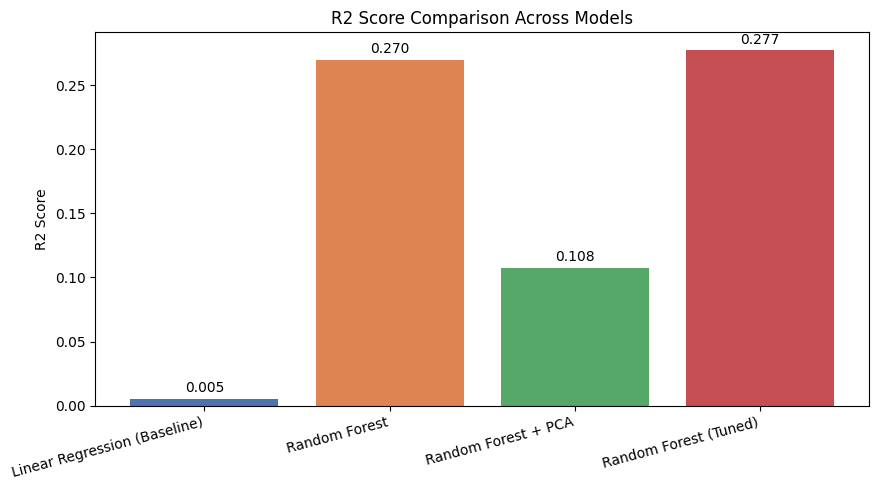

In [50]:
# Visualize R2 comparison
plt.figure(figsize=(9, 5))
bars = plt.bar(results['Model'], results['R2'], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.ylabel('R2 Score')
plt.title('R2 Score Comparison Across Models')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, results['R2']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center')
plt.tight_layout()
plt.show()

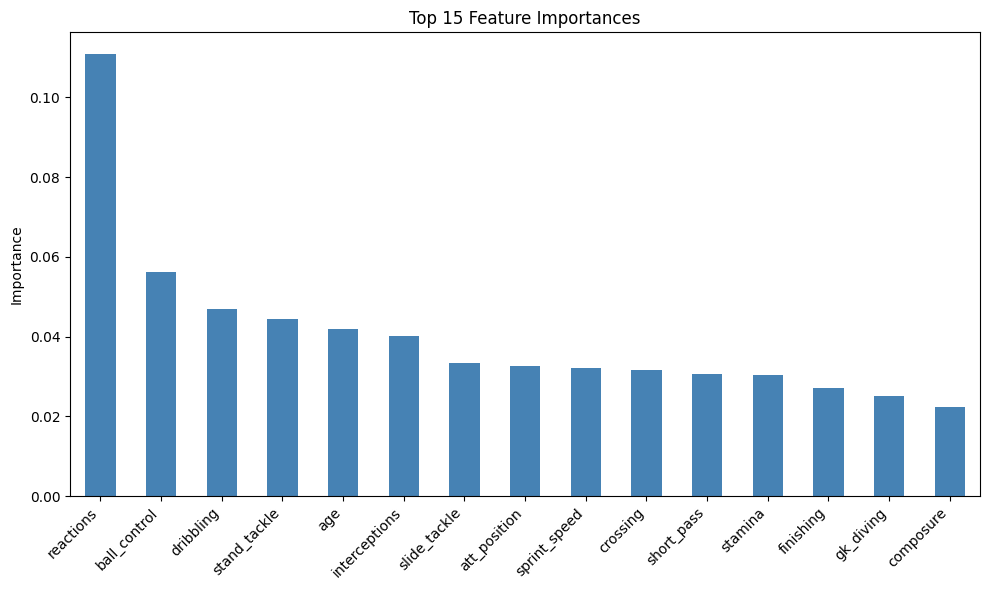

In [51]:
feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar', color='steelblue')
plt.title('Top 15 Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()